<a href="https://colab.research.google.com/github/Miguithub/Wavelets/blob/main/Wavelets_VNP_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# LIBRERIAS 1

In [1]:
!pip install statsmodels

In [2]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


---

# DE

In [4]:
btc = pd.read_parquet('/content/drive/MyDrive/mf12024.parquet')

In [ ]:
# eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
# sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [5]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   open_time               int64  
 1   open                    float64
 2   high                    float64
 3   low                     float64
 4   close                   float64
 5   volume                  float64
 6   close_time              int64  
 7   quote_volume            float64
 8   trade_count             int64  
 9   taker_buy_base_volume   float64
 10  taker_buy_quote_volume  float64
 11  ignore                  int64  
dtypes: float64(8), int64(4)
memory usage: 2.8 GB


In [ ]:
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
31622395,1735689595000,93576.00,93576.01,93576.00,93576.01,0.00083,1735689595999,77.668087,2,0.00067,62.695927,0
31622396,1735689596000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689596999,0.000000,0,0.00000,0.000000,0
31622397,1735689597000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689597999,0.000000,0,0.00000,0.000000,0
31622398,1735689598000,93576.01,93576.01,93576.01,93576.01,0.00094,1735689598999,87.961449,3,0.00094,87.961449,0
31622399,1735689599000,93576.00,93576.00,93576.00,93576.00,0.00217,1735689599999,203.059920,3,0.00000,0.000000,0


In [ ]:
btc.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,1704067200000,42283.58,42283.59,42283.58,42283.58,0.07625,1704067200999,3224.123141,21,0.01658,701.061922,0
1,1704067201000,42283.59,42283.59,42283.58,42283.58,1.37528,1704067201999,58151.769471,51,0.75683,32001.489420,0
2,1704067202000,42283.58,42283.59,42283.58,42283.58,0.18867,1704067202999,7977.643051,9,0.00124,52.431652,0
3,1704067203000,42283.58,42283.59,42283.58,42283.59,0.83488,1704067203999,35301.720464,39,0.51935,21959.982467,0
4,1704067204000,42283.58,42283.59,42283.58,42283.59,0.23809,1704067204999,10067.297927,17,0.03653,1544.619543,0


Cleaness

In [6]:
import pandas as pd

# Usá el nombre real de tu columna temporal
t = pd.to_datetime(btc["close_time"])

# diferencias entre timestamps en segundos
d = t.diff().dt.total_seconds()

# chequeo de equidistancia
es_equidistante = d.iloc[1:].nunique() == 1

print("Equidistante:", es_equidistante)
print("Intervalo único (segundos):", d.iloc[1] if es_equidistante else "No uniforme")

Equidistante: True
Intervalo único (segundos): 1e-06


In [7]:
del t, d
import gc
gc.collect()

17

In [8]:
btc.drop(columns=btc.columns[0], inplace=True)
btc["time"] = pd.to_datetime(btc["close_time"] // 1000, unit="s")
cols = ["time"] + [c for c in btc.columns if c not in ["time", "close_time"]]
btc = btc[cols]

In [9]:
btc["day"] = btc["time"].dt.weekday + 1
btc.loc[btc["day"] == 7, "day"] = 0

In [ ]:
btc.tail()

,time,open,high,low,close,volume,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore,day
31622395,2024-12-31 23:59:55,93576.00,93576.01,93576.00,93576.01,0.00083,77.668087,2,0.00067,62.695927,0,2
31622396,2024-12-31 23:59:56,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622397,2024-12-31 23:59:57,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622398,2024-12-31 23:59:58,93576.01,93576.01,93576.01,93576.01,0.00094,87.961449,3,0.00094,87.961449,0,2
31622399,2024-12-31 23:59:59,93576.00,93576.00,93576.00,93576.00,0.00217,203.059920,3,0.00000,0.000000,0,2


In [10]:
cols = ["time", "day"] + [c for c in btc.columns if c not in ["time", "day"]]
btc = btc[cols]

In [11]:
btc["close_ln"] = np.log(btc["close"])

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   time                    datetime64[ns]
 1   day                     int64         
 2   open                    float64       
 3   high                    float64       
 4   low                     float64       
 5   close                   float64       
 6   volume                  float64       
 7   quote_volume            float64       
 8   trade_count             int64         
 9   taker_buy_base_volume   float64       
 10  taker_buy_quote_volume  float64       
 11  ignore                  int64         
 12  close_ln                float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 3.1 GB


#Wlts VB non parametric

## r_10 *


In [ ]:
df10 = btc.iloc[:, [0, 1, 5, 12]]
df10 = df10.iloc[::10].copy()
df10["r"] = df10["close_ln"].diff()
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 120.6 MB


Media: 2.5120653730677365e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.000290376799758221
Skew: -0.6644163965928828
Deciles:
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
d5 : 0.0
d6 : 1.5112582580911745e-07
d7 : 4.940751749771264e-05
d8 : 0.00013040859643567173
d9 : 0.00026780246966211566
Percentiles mas altos:
d95 : 0.00041478295868806436
d96 : 0.0004653834598781969
d97 : 0.0005335308049401632
d98 : 0.0006348627043620058
d99 : 0.00082801840637032
d100 : 0.01430715525476245
Permiles
p970 : 0.0005335308049401632
p971 : 0.000541870576748817
p972 : 0.0005504572842127686
p973 : 0.0005592279938695307
p974 : 0.0005682853087387143
p975 : 0.0005778918045185033
p976 : 0.0005881440891452153
p977 : 0.0005988980718875149
p978 : 0.0006100198064358578
p979 : 0.0006219765619111564
p980 : 0.0006348627043620058
p981 : 0.0006483678177292883
p982 : 0.0006626566118075346
p983 : 0.0006780131169875573
p984 : 0.000694884315670125
p985 : 0

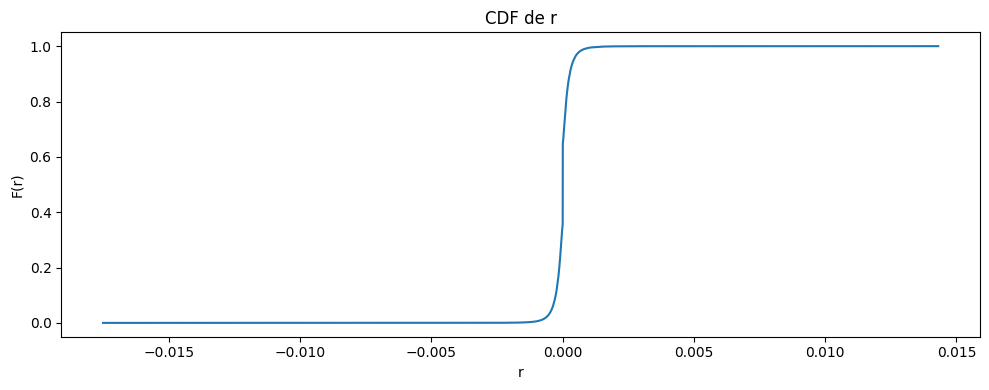

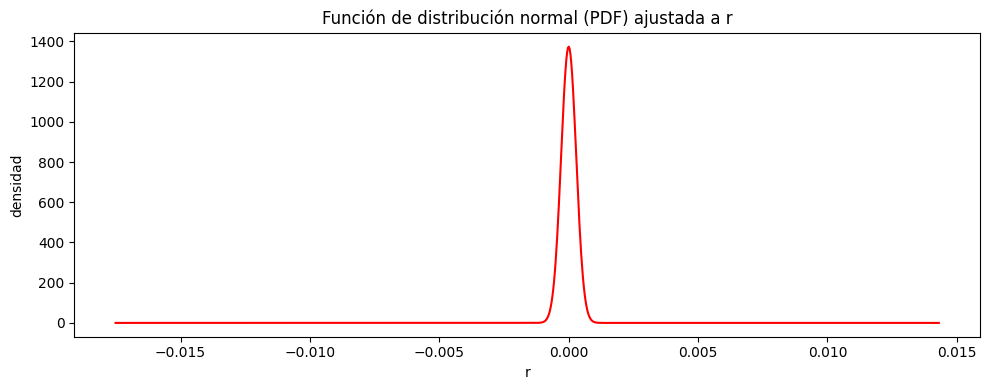

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df10["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df10["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.983487          0.016513        0.018851   
1    sym6  6      0.983535          0.016465        0.028615   
2     db6  6      0.983684          0.016316        0.029370   
3    sym4  6      0.983506          0.016494        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        1.349098   788.172962  
1             0.003599        1.346415  1527.291776  
2             0.003750        1.346673  1623.675248  
3             0.003572        1.344478  1625.363930  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00458471 0.00918803 0.01832132 0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.01748336 0.03503767 0.06986659 0.13629791 0.26193334 0.47938114]


## r_15 **


In [12]:
df15 = btc.iloc[:, [0, 1, 5, 12]]
df15 = df15.iloc[::15].copy()
df15["r"] = df15["close_ln"].diff()
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 80.4 MB


Media: 3.76809916230909e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00036078789699599685
Skew: -0.5918241943710671
Deciles:
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
d5 : 0.0
d6 : 2.3319833459822805e-07
d7 : 8.111270573536418e-05
d8 : 0.00017403621973635124
d9 : 0.0003386397390165995
Percentiles mas altos:
d95 : 0.000516697122034948
d96 : 0.0005783330969144623
d97 : 0.0006613860042640953
d98 : 0.0007849116275486496
d99 : 0.00102082375687722
d100 : 0.019740671452751712
Permiles
p970 : 0.0006613860042640953
p971 : 0.0006712843939121873
p972 : 0.0006818457931035193
p973 : 0.0006923294869505018
p974 : 0.0007035229648896201
p975 : 0.000715536563801589
p976 : 0.0007285188955464288
p977 : 0.0007417317042810429
p978 : 0.0007551259786533746
p979 : 0.0007697478319800725
p980 : 0.0007849116275486496
p981 : 0.0008006253623015165
p982 : 0.0008188651597057585
p983 : 0.0008375312170303781
p984 : 0.0008576397359220929
p985 : 0.000

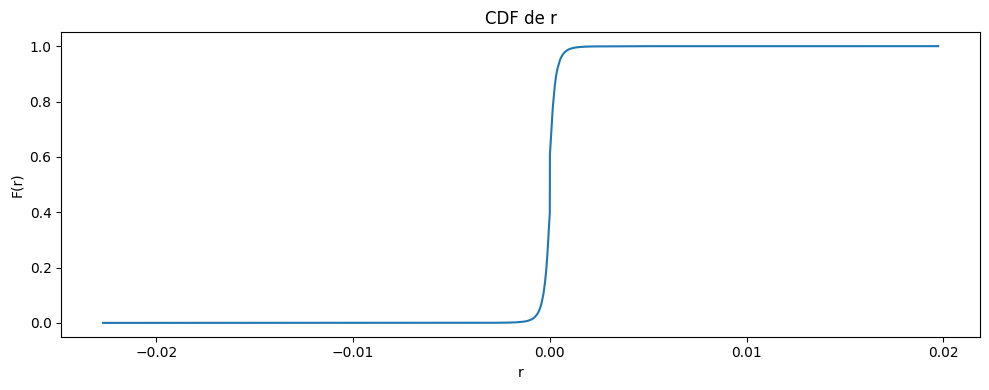

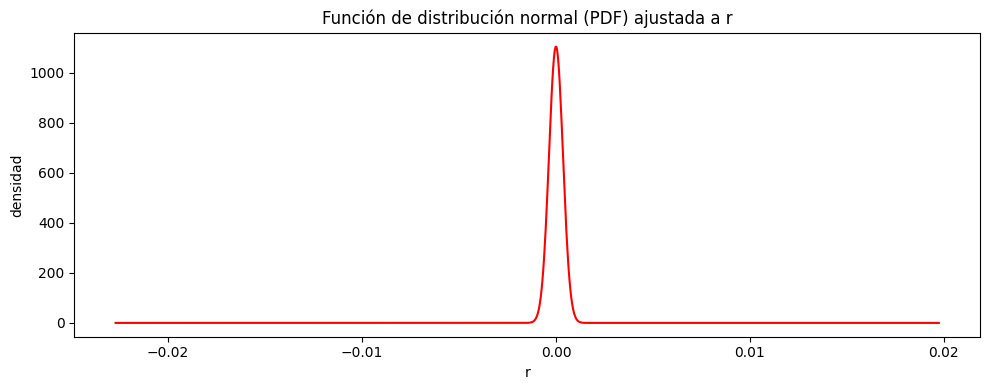

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df15["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df15["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1040912948216904
P0 (eps): 0.1040912948216904
d0 : -0.02270720738637877
d1 : -0.0003371947044797707
d2 : -0.0001732940764942015
d3 : -8.093561576139052e-05
d4 : -2.400407861813392e-07
Percentiles mas bajos:
d0 : -0.0010524389561297482
d1 : -0.000798699366188714
d2 : -0.000668114432760035
d3 : -0.000582131826901005
d4 : -0.0005192846253105614
d5 : -0.00047030662868812807
d6 : -0.0004299274431113105
d7 : -0.00039582443766040143
d8 : -0.0003657379544529
d9 : -0.0003397565633194226
d10 : -0.0003161667496839229
d11 : -0.0002952106950851245
d12 : -0.00027621478841250634
d13 : -0.0002581737193119658
d14 : -0.00024143300978510143
d15 : -0.00022618347367818356
d16 : -0.0002116719089413621
d17 : -0.00019894742109004683
d18 : -0.00018618756073452404
d19 : -0.00017440182492616427


wavelet

In [13]:
import numpy as np
import pandas as pd
import pywt

x = df15["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.984283          0.015717        0.010111   
1    sym6  6      0.984193          0.015807        0.027775   
2    sym4  6      0.984177          0.015823        0.029308   
3     db6  6      0.984326          0.015674        0.030858   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003614        1.330457   430.287597  
1             0.004873        1.326638  1241.829204  
2             0.004746        1.323769  1270.757320  
3             0.005486        1.324153  1573.084635  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.0044936  0.0090157  0.01846812 0.03457333 0.07175279 0.13179832]
Shares por nivel (J...1):
[0.0166367  0.03337887 0.06837465 0.12800108 0.26565086 0.48795784]


##vnp

Energia local suavizada

In [14]:
import numpy as np, pywt

x = df15["r"].to_numpy(dtype=float)
x = np.nan_to_num(x, nan=0.0)  # si tenés NaN, swt revienta; mejor imputación simple

J = 6
w = "db4"
n = x.size
m = 1 << J
pad = (-n) % m
xp = np.pad(x, (0, pad), mode="edge") if pad else x

coeffs = pywt.swt(xp, w, level=J, trim_approx=False)

# Detalles por nivel (misma longitud que xp)
for j in range(1, J + 1):
    df15[f"j{j}"] = coeffs[j-1][1][:n]   # cDj
df15[f"a{J}"] = coeffs[-1][0][:n]        # cAJ

In [15]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 12 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   j1        float64       
 6   j2        float64       
 7   j3        float64       
 8   j4        float64       
 9   j5        float64       
 10  j6        float64       
 11  a6        float64       
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 193.0 MB


Bloque elegido:
Inicio: 2024-06-07 21:07:27
Fin   : 2024-06-07 21:12:27


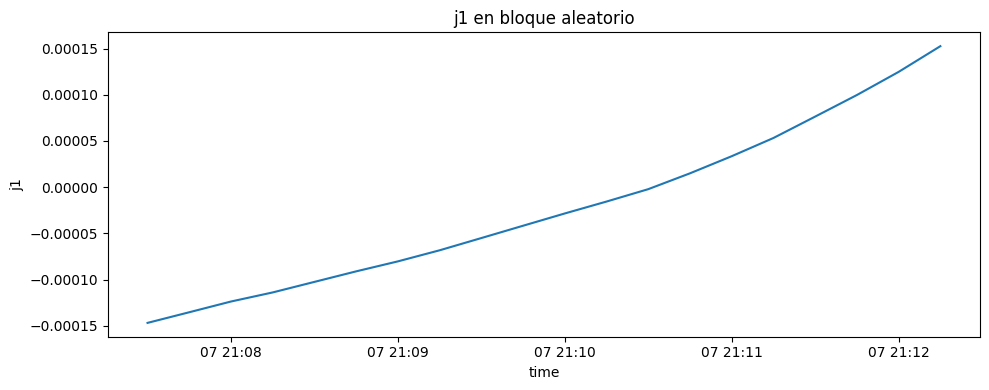

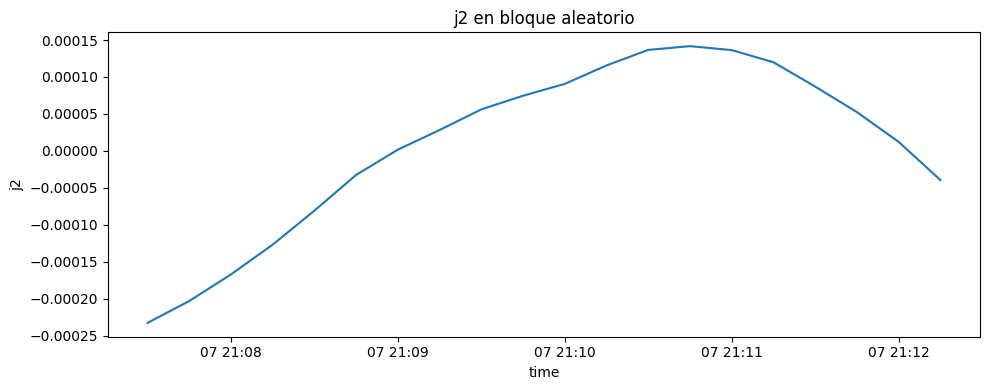

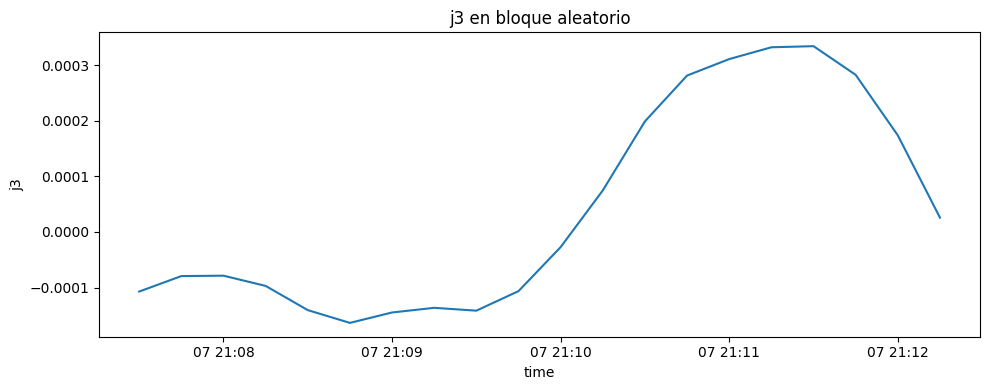

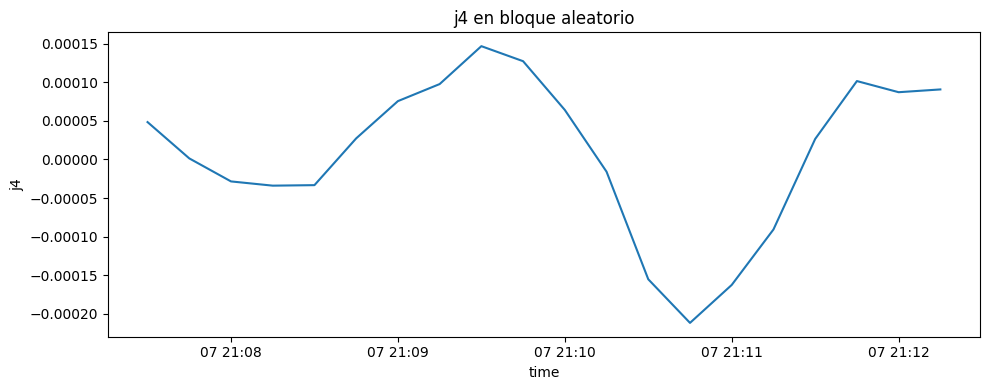

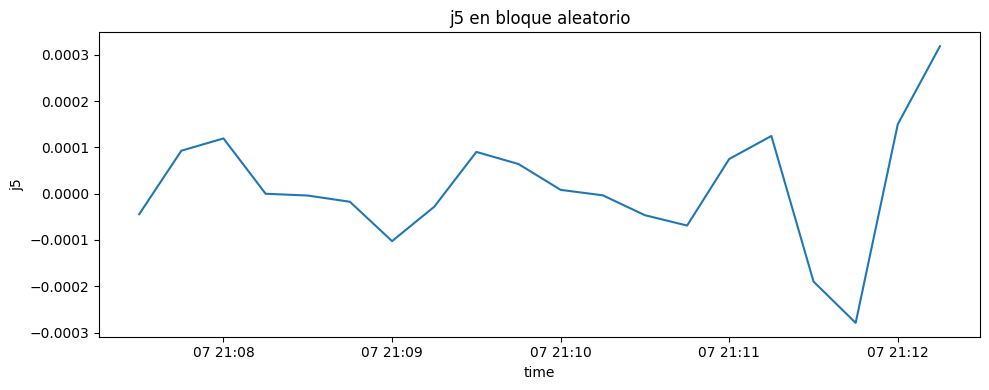

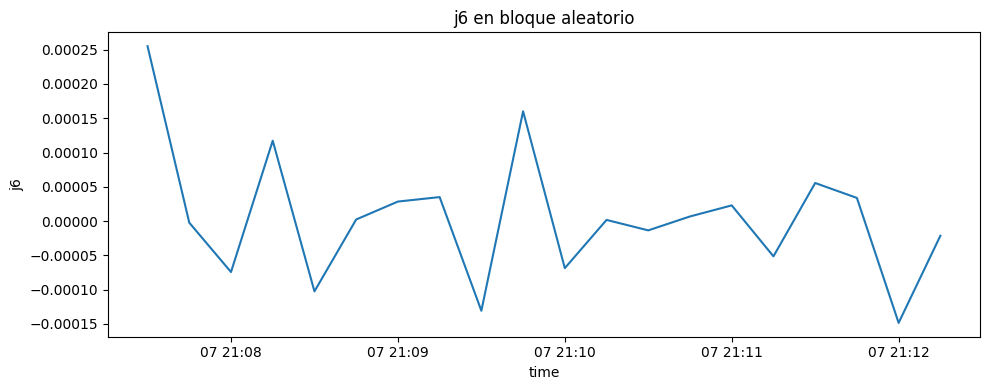

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 7)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

In [16]:
for j in range(1, 7):
    c = df15[f"j{j}"]
    df15[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

Bloque elegido:
Inicio: 2024-11-02 01:47:07
Fin   : 2024-11-02 01:52:07


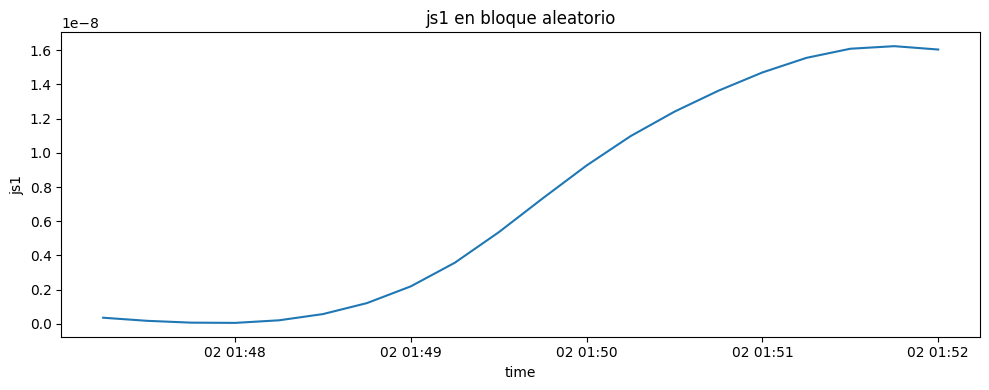

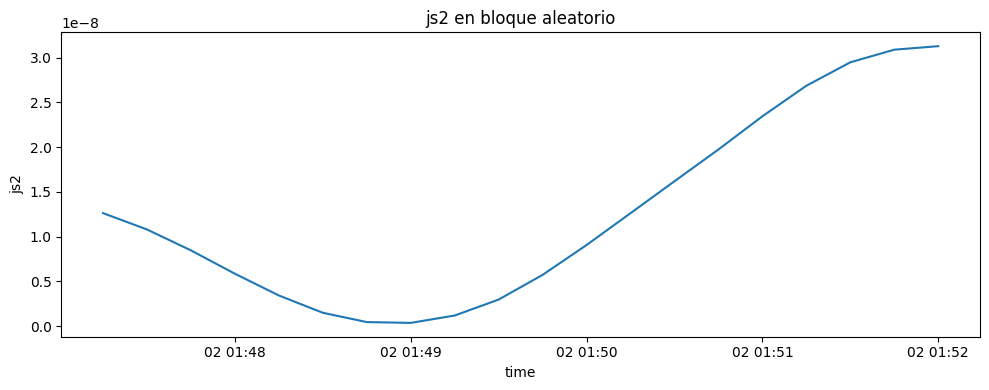

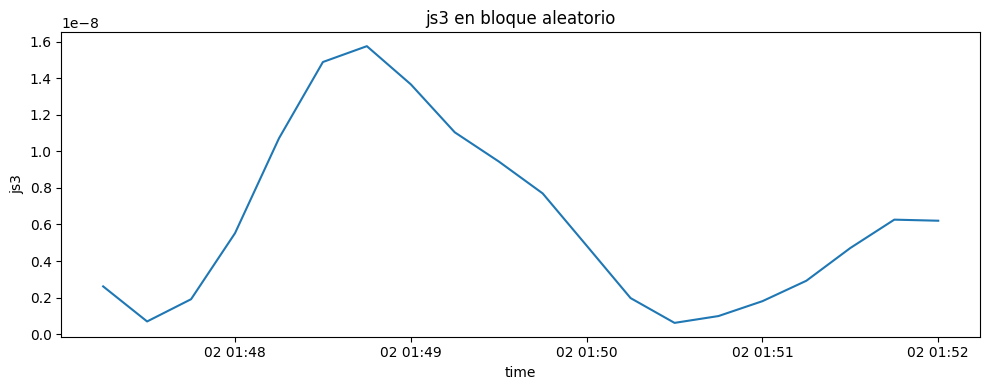

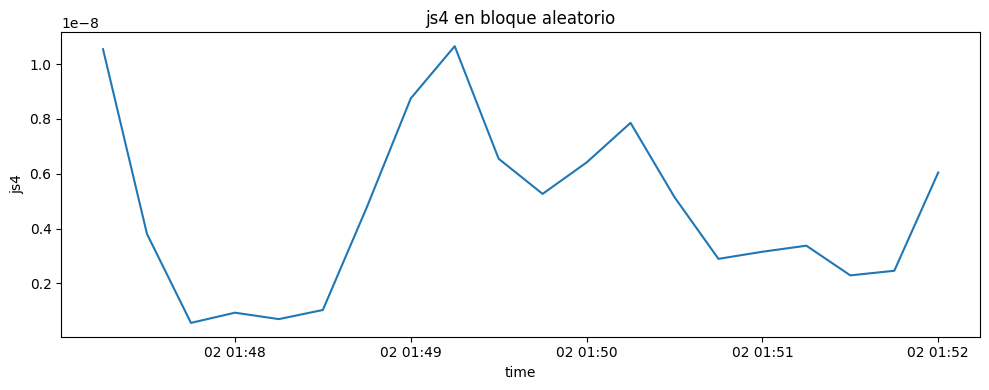

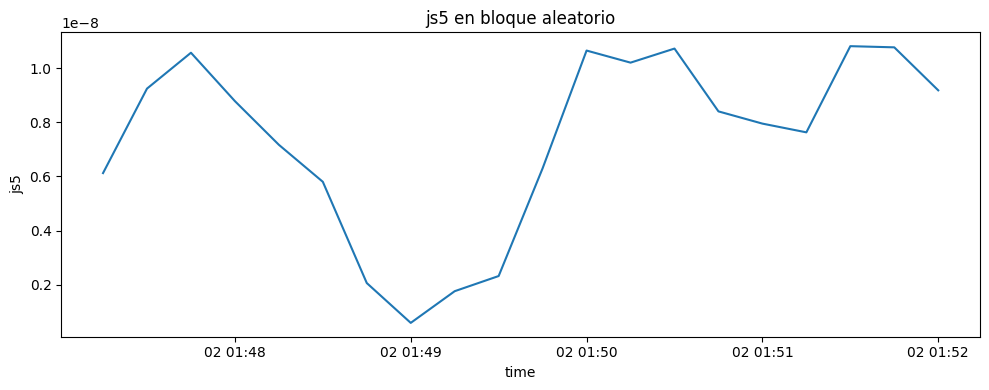

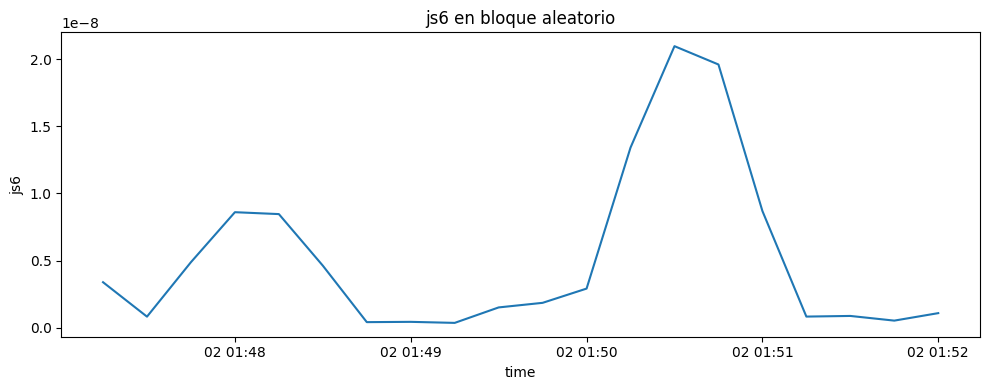

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 7)]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()


Eshort, Emedium and ELong all dirty

In [17]:
df15["des"] = df15["j1"] + df15["j2"]
df15["dem"] = df15["j3"] + df15["j4"]
df15["del"] = df15["j5"] + df15["j6"]

In [ ]:
s = df15["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df15["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df15["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 0
des Nulls: 0
dem Ceros: 0
dem Nulls: 0
del Ceros: 0
del Nulls: 0


In [18]:
df15["de_total"] = df15["des"] + df15["dem"] + df15["del"]

In [19]:
df15["dvol_wlt"] = np.sqrt(df15["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [20]:
df15["dlog_vol_wlt"] = np.log(df15["dvol_wlt"])

Eshort, Emedium and ELong all clean

In [21]:
df15["es"] = df15["js1"] + df15["js2"]
df15["em"] = df15["js3"] + df15["js4"]
df15["el"] = df15["js5"] + df15["js6"]

In [ ]:
s = df15["es"]
print("es Ceros:", (s == 0).sum())
print("es Nulls:", s.isna().sum())
s = df15["em"]
print("em Ceros:", (s == 0).sum())
print("em Nulls:", s.isna().sum())
s = df15["el"]
print("el Ceros:", (s == 0).sum())
print("el Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

es Ceros: 0
es Nulls: 0
em Ceros: 0
em Nulls: 0
el Ceros: 0
el Nulls: 0


In [ ]:
# dado que no hay ceros va sin epsilon

Bloque elegido:
Inicio: 2024-07-19 16:56:33
Fin   : 2024-07-19 17:01:33


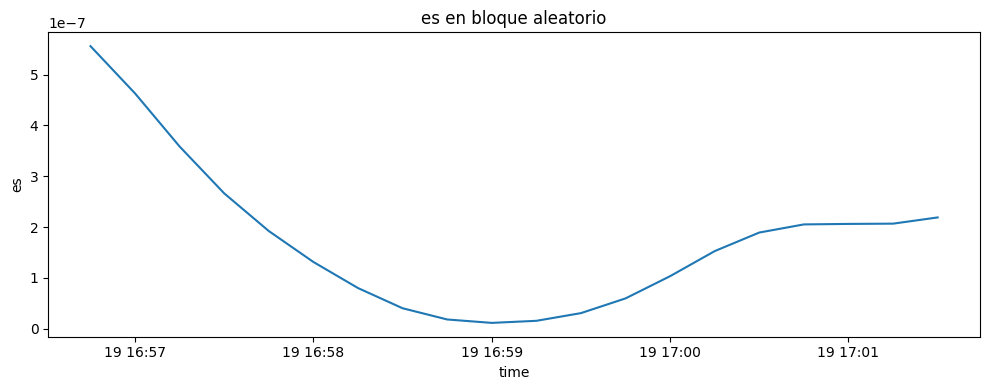

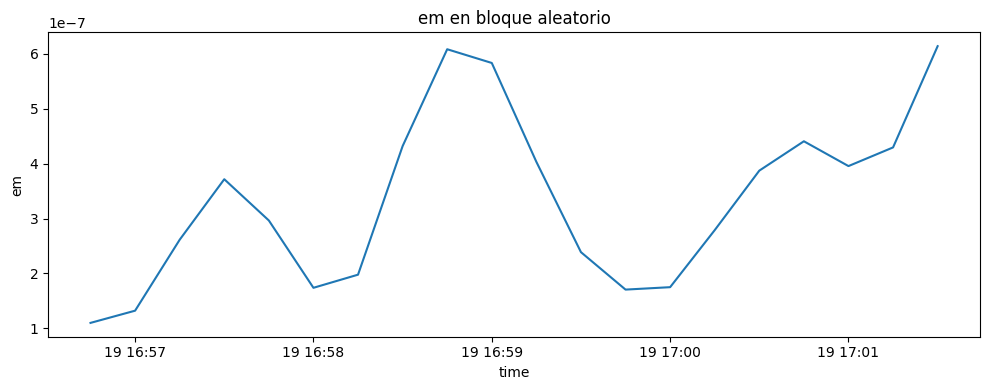

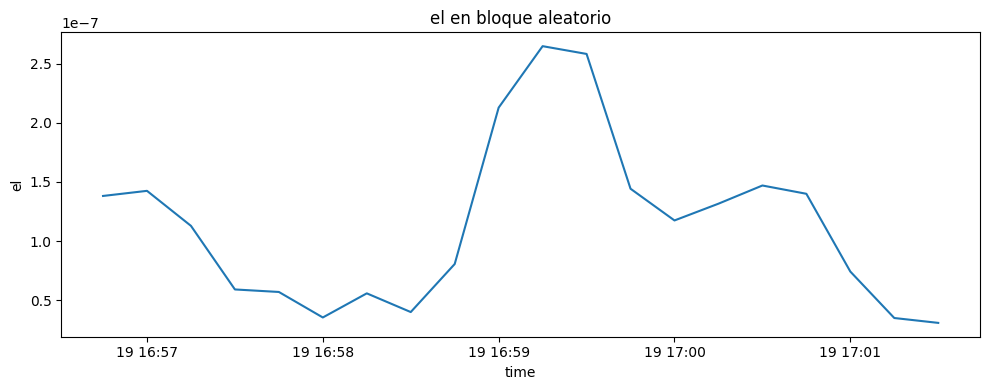

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el"]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em y el
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()


Energia log-relativa

In [24]:
df15["e_total"] = df15["es"] + df15["em"] + df15["el"]
s = df15["e_total"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


In [25]:
df15["ers"] = np.log((df15["es"]) / df15["e_total"])
df15["erm"] = np.log((df15["em"]) / df15["e_total"])
df15["erl"] = np.log((df15["el"]) / df15["e_total"])

In [ ]:
df15.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2108160 entries, 0 to 31622385
Data columns (total 25 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   j1        float64       
 6   j2        float64       
 7   j3        float64       
 8   j4        float64       
 9   j5        float64       
 10  j6        float64       
 11  a6        float64       
 12  js1       float64       
 13  js2       float64       
 14  js3       float64       
 15  js4       float64       
 16  js5       float64       
 17  js6       float64       
 18  es        float64       
 19  em        float64       
 20  el        float64       
 21  e_total   float64       
 22  ers       float64       
 23  erm       float64       
 24  erl       float64       
dtypes: datetime64[ns](1), float64(23), int64(1)
memory usage: 402.1 MB


Bloque elegido:
Inicio: 2024-04-20 17:11:43
Fin   : 2024-04-20 17:41:43


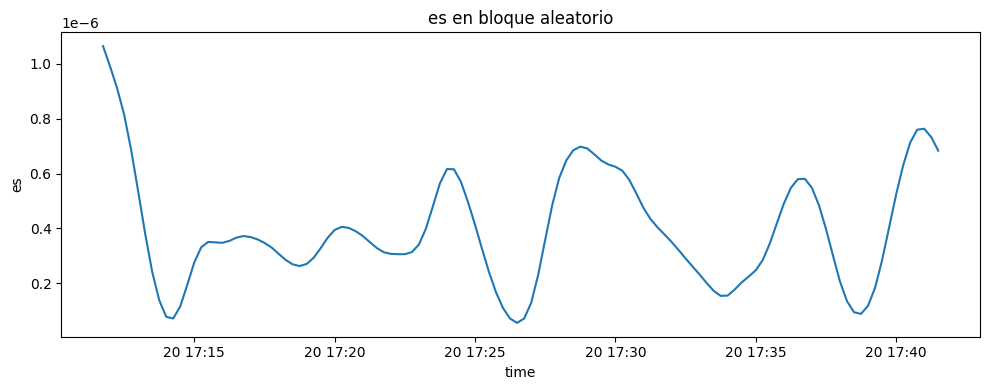

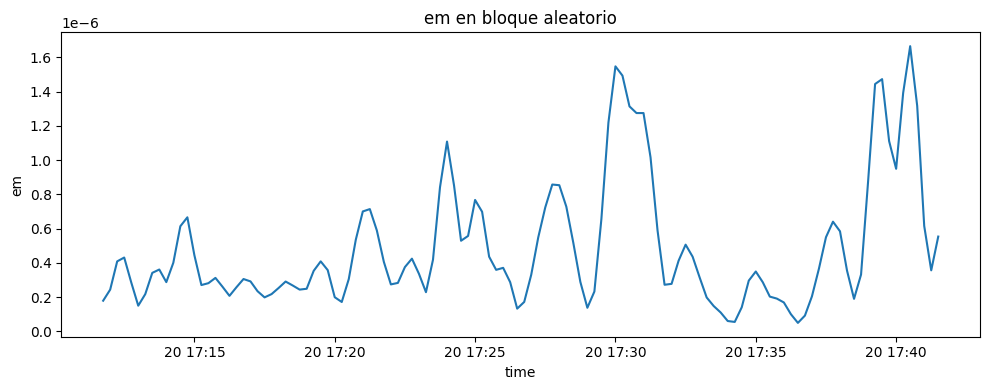

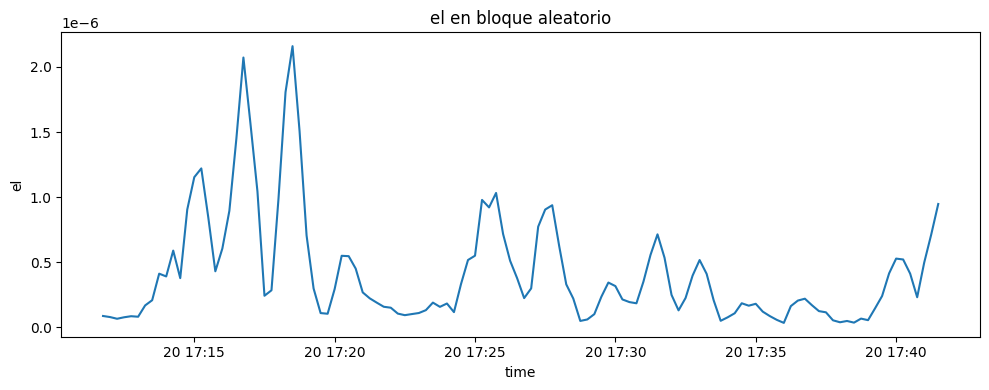

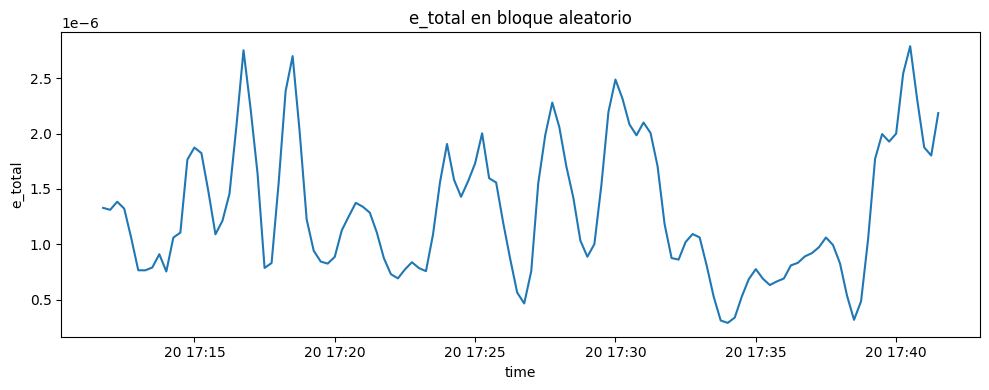

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df15["time"] = pd.to_datetime(df15["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df15["time"].min()
t_max = df15["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=30)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_e = ["es", "em", "el", "e_total"]
mask = (df15["time"] >= t_inicio) & (df15["time"] < t_fin)
sub = df15.loc[mask, ["time"] + cols_e].dropna()

# 3) Graficar es, em, el y e_total
for c in cols_e:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[c])
    plt.title(f"{c} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(c)
    plt.tight_layout(); plt.show()

In [26]:
df15["vol_wlt"] = np.sqrt(df15["e_total"])

In [ ]:
s = df15["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 0


In [27]:
df15["log_vol_wlt"] = np.log(df15["vol_wlt"])

"

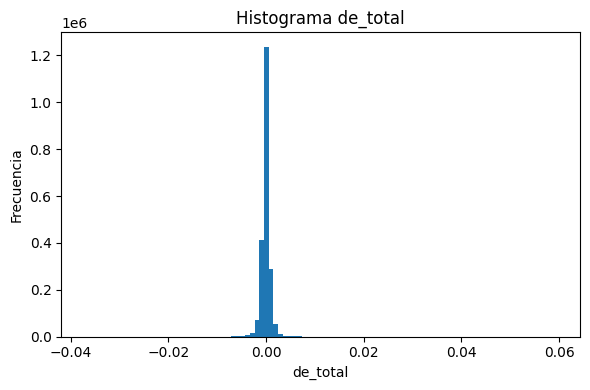

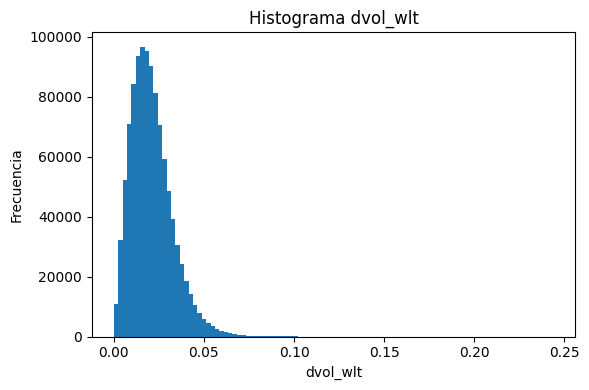

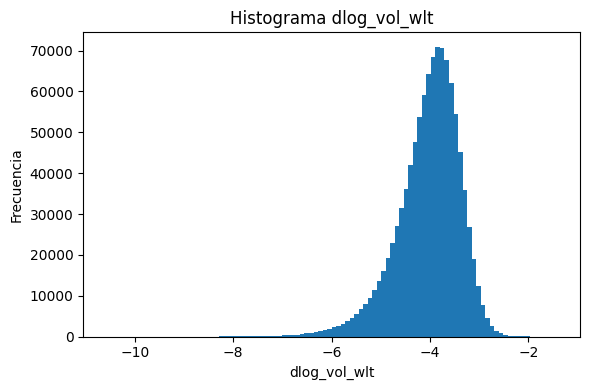

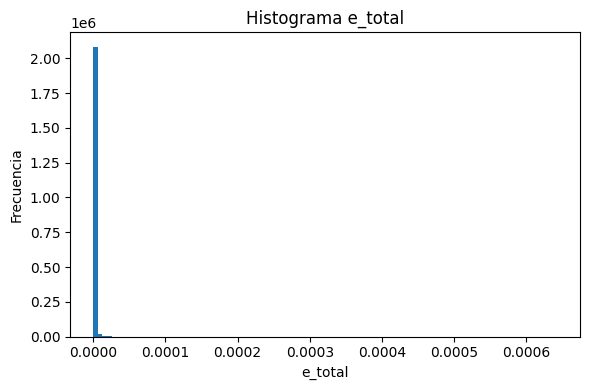

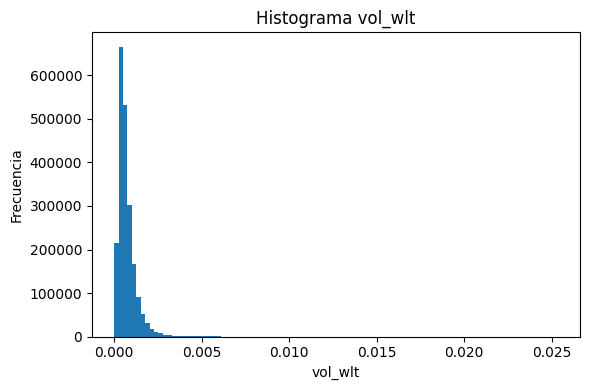

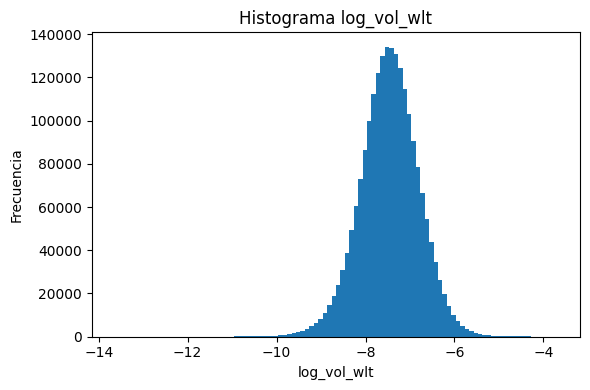

In [ ]:
import matplotlib.pyplot as plt
# Histograma de_total
plt.figure(figsize=(6,4))
plt.hist(df15["de_total"].dropna(), bins=100)
plt.title("Histograma de_total")
plt.xlabel("de_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dvol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["dvol_wlt"].dropna(), bins=100)
plt.title("Histograma dvol_wlt")
plt.xlabel("dvol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma dlog_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["dlog_vol_wlt"].dropna(), bins=100)
plt.title("Histograma dlog_vol_wlt")
plt.xlabel("dlog_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df15["e_total"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df15["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Individual checks

In [28]:
import numpy as np
from scipy.stats import skew

s = df15["log_vol_wlt"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)



print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)

Media: -7.462308926273783
Mediana: -7.455560093497798
Moda: -13.653599638206268
Desvío estándar: 0.6596274852434844
Skew: -0.14074585232031617


In [29]:
# Moda por bindeo (más representativa)
counts, bins = np.histogram(s, bins=100)
moda_real = bins[np.argmax(counts)]
print("moda bins:", moda_real)

moda bins: -7.566874573191112


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

s = df15["log_vol_wlt"].dropna()

# 1) Deciles + permil 0.005 (0.5%)
deciles = s.quantile(np.arange(0.1, 1.0, 0.1)).tolist()
p0005 = s.quantile(0.005)
print("Deciles (0.1..0.9):", deciles)
print("Permil 0.005:", p0005)

# 2) Autocorrelación: primeros 20 lags + gráfica
acf_vals = acf(s.values, nlags=20, fft=True)  # incluye lag 0
print("\nACF primeros 20 lags (lag: valor):")
for lag, val in enumerate(acf_vals[:21]):
    print(f"{lag:>2}: {val:.6f}")

plt.figure(figsize=(10,4))
plot_acf(s, lags=20, zero=True)
plt.title("ACF: log_vol_wlt (0..20 lags)")
plt.tight_layout()
plt.show()

# 3) Top 5 días con más observaciones <= permil 0.005
d = df15.loc[df15["log_vol_wlt"].le(p0005), ["time"]].dropna()
top5 = (d.assign(day=d["time"].dt.date)
         .groupby("day").size()
         .sort_values(ascending=False)
         .head(5))
print("\nTop 5 días con más obs <= permil 0.005:")
print(top5)

In [30]:
s = df15["log_vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 0


In [31]:
# Realized Variance
df15["RV_r"] = df15["r"]**2

In [32]:
# Limpieza mínima
s = df15[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.16557027358617013
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [34]:
# Limpieza mínima
s = df15[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.4228209095367485
Spearman: 0.5153190529978882
Kendall : 0.3602789997613362


In [ ]:
import statsmodels.api as sm

# Datos
y = df15["RV_r"]
X = df15["log_vol_wlt"]

# Limpieza mínima
mask = y.notna() & X.notna()
y = y[mask]
X = X[mask]

# OLS
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Estadísticos clave
print("Coeficientes:")
print(model.params, "\n")

print("R2:", model.rsquared)
print("R2 ajustado:", model.rsquared_adj)
print("F-stat:", model.fvalue)
print("p-value (F):", model.f_pvalue)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("\nResumen completo:")
print(model.summary())

Bloques

In [35]:
# Asegurar datetime
df15["time"] = pd.to_datetime(df15["time"])

# Setear índice temporal
df15_ = df15.set_index("time")

# Agregación a 15 minutos
df5m = df15_.resample("5T").agg({
    "RV_r": "sum",
    "e_total": "sum",
    "de_total": "sum",
    "log_vol_wlt": "mean",
    "vol_wlt": "mean"
}).reset_index()

df5m.head()

/tmp/ipython-input-277755125.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df5m = df15_.resample("5T").agg({


,time,RV_r,e_total,de_total,log_vol_wlt,vol_wlt
0,2024-01-01 00:00:00,1.139686e-06,0.000004,-0.005786,-7.740164,0.000440
1,2024-01-01 00:05:00,6.450701e-07,0.000005,0.001273,-7.581748,0.000516
2,2024-01-01 00:10:00,7.303034e-07,0.000007,-0.005835,-7.483053,0.000584
3,2024-01-01 00:15:00,1.644573e-06,0.000009,-0.001419,-7.337899,0.000658
4,2024-01-01 00:20:00,3.923958e-07,0.000005,-0.004291,-7.705582,0.000467


In [36]:
# Limpieza mínima
s = df5m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.37654537193217874
Spearman: 0.9138267375567589
Kendall : 0.7538350428694848


In [38]:
# Limpieza mínima
s = df5m[["RV_r", "e_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_total"], method="pearson")
spearman = s["RV_r"].corr(s["e_total"], method="spearman")
kendall  = s["RV_r"].corr(s["e_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.8774666526779349
Spearman: 0.9189316864022443
Kendall : 0.7635214552776779


In [39]:
import statsmodels.api as sm

# Datos
y = df5m["RV_r"]
X = df5m["log_vol_wlt"]

# Limpieza mínima
mask = y.notna() & X.notna()
y = y[mask]
X = X[mask]

# OLS
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Estadísticos clave
print("Coeficientes:")
print(model.params, "\n")

print("R2:", model.rsquared)
print("R2 ajustado:", model.rsquared_adj)
print("F-stat:", model.fvalue)
print("p-value (F):", model.f_pvalue)
print("AIC:", model.aic)
print("BIC:", model.bic)

print("\nResumen completo:")
print(model.summary())

Coeficientes:
const          0.000046
log_vol_wlt    0.000006
dtype: float64 

R2: 0.14178641712354334
R2 ajustado: 0.14177827514317332
F-stat: 17414.2420739053
p-value (F): 0.0
AIC: -2152444.4309248077
BIC: -2152425.2997371806

Resumen completo:
                            OLS Regression Results                            
Dep. Variable:                   RV_r   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                 1.741e+04
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        23:12:32   Log-Likelihood:             1.0762e+06
No. Observations:              105408   AIC:                        -2.152e+06
Df Residuals:                  105406   BIC:                        -2.152e+06
Df Model:                           1                                         
Covariance Type:            nonrobust     

# CVS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


SAVE

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Ruta donde querés guardar el archivo (podés cambiar el nombre o carpeta)
ruta_guardado = '/content/drive/MyDrive/VFJmf1.parquet'

# Guardar en formato Parquet, conservando la estructura y tipos
mf1.to_parquet(ruta_guardado, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


APERTURA

In [ ]:
mf1 = pd.read_parquet('/content/drive/MyDrive/VFmf1.parquet')

KeyboardInterrupt: 

In [ ]:
mf1.info()